# ML Regression Fault PoC (YAML + Residual Rules)

Beginner proof-of-concept:
- YAML defines model/fault settings
- a simple linear regression predicts expected behavior
- a residual threshold creates a fault flag

Data: /home/ben/open-fdd/examples/data/AHU7.csv
Rows: 10213
Feature: Clg Vlv Cmd (%) -> duct_pressure
Target:  OA Damper Cmd (%) -> fan_speed_pct
Fitted line: fan_speed_pct ~= 0.2170 * duct_pressure + 4.9227
Fault count (ml_residual_fault_flag): 2372


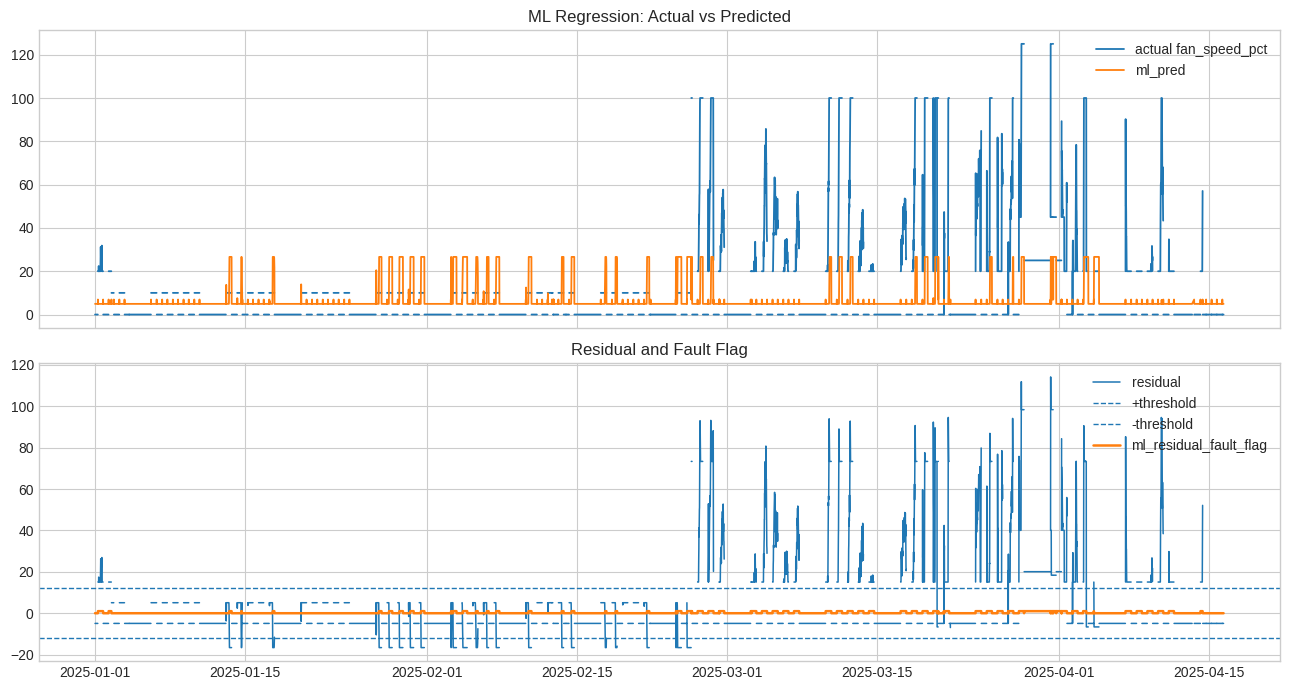

,sum,count,fault_rate
month,,,
2025-01,258,2997,0.086086
2025-02,463,2724,0.169971
2025-03,1243,3011,0.412820
2025-04,408,1481,0.275490


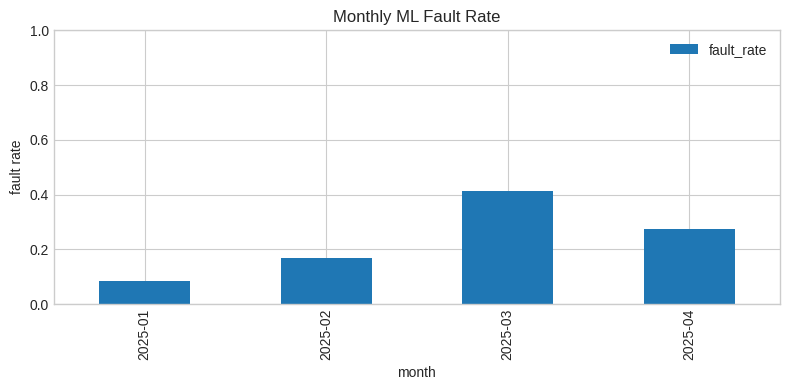

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

plt.style.use("seaborn-v0_8-whitegrid")

cwd = Path.cwd().resolve()
candidates = [cwd / "examples" / "data", cwd / "data", cwd.parent / "data"]
DATA_DIR = next((p for p in candidates if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate examples/data directory.")

csv_path = DATA_DIR / "AHU7.csv"
df_raw = pd.read_csv(csv_path)
ts_col = next((c for c in df_raw.columns if "time" in c.lower()), None)
if ts_col is None:
    raise ValueError("No timestamp-like column found.")

ts = pd.to_datetime(df_raw[ts_col].astype(str).str.strip(), format="%d-%b-%y %I:%M:%S %p EST", errors="coerce")
if ts.notna().sum() == 0:
    ts = pd.to_datetime(df_raw[ts_col], errors="coerce")

df_raw[ts_col] = ts
df_raw = df_raw.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)

numeric_cols = [c for c in df_raw.columns if c != ts_col and pd.api.types.is_numeric_dtype(df_raw[c])]
if len(numeric_cols) < 2:
    raise ValueError("Need at least two numeric columns.")

feature_col = numeric_cols[0]
target_col = numeric_cols[1]
df = df_raw[[ts_col, feature_col, target_col]].copy()
df.columns = ["timestamp", "duct_pressure", "fan_speed_pct"]

yaml_config = """
model:
  type: linear_regression
  feature: duct_pressure
  target: fan_speed_pct
fault_rule:
  residual_abs_threshold: 12.0
  fault_flag_name: ml_residual_fault_flag
"""
cfg = yaml.safe_load(yaml_config)

split_idx = int(len(df) * 0.7)
train = df.iloc[:split_idx].copy()

x_train = train[cfg['model']['feature']].to_numpy(dtype=float)
y_train = train[cfg['model']['target']].to_numpy(dtype=float)
mask = np.isfinite(x_train) & np.isfinite(y_train)
x_train = x_train[mask]
y_train = y_train[mask]

if len(x_train) < 2 or np.nanstd(x_train) < 1e-12:
    # Safe fallback when source data is too flat or sparse
    m, b = 0.0, float(np.nanmean(y_train) if len(y_train) else 0.0)
else:
    m, b = np.polyfit(x_train, y_train, 1)

x_all = df[cfg['model']['feature']].to_numpy(dtype=float)
df['ml_pred'] = m * np.nan_to_num(x_all, nan=float(np.nanmean(x_train) if len(x_train) else 0.0)) + b

n = len(df)
a0 = int(n * 0.82)
a1 = min(a0 + max(20, int(n * 0.04)), n - 1)
df.loc[a0:a1, 'fan_speed_pct'] = df.loc[a0:a1, 'fan_speed_pct'] + 25.0

df['residual'] = df[cfg['model']['target']] - df['ml_pred']
thr = float(cfg['fault_rule']['residual_abs_threshold'])
flag_col = cfg['fault_rule']['fault_flag_name']
df[flag_col] = (df['residual'].abs() > thr).astype(int)

print(f"Data: {csv_path}")
print(f"Rows: {len(df)}")
print(f"Feature: {feature_col} -> duct_pressure")
print(f"Target:  {target_col} -> fan_speed_pct")
print(f"Fitted line: fan_speed_pct ~= {m:.4f} * duct_pressure + {b:.4f}")
print(f"Fault count ({flag_col}): {int(df[flag_col].sum())}")

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(df['timestamp'], df['fan_speed_pct'], label='actual fan_speed_pct', linewidth=1.3)
ax[0].plot(df['timestamp'], df['ml_pred'], label='ml_pred', linewidth=1.3)
ax[0].set_title('ML Regression: Actual vs Predicted')
ax[0].legend(loc='upper right')

ax[1].plot(df['timestamp'], df['residual'], label='residual', linewidth=1.1)
ax[1].axhline(thr, linestyle='--', linewidth=1, label='+threshold')
ax[1].axhline(-thr, linestyle='--', linewidth=1, label='-threshold')
ax[1].plot(df['timestamp'], df[flag_col], label=flag_col, linewidth=1.8)
ax[1].set_title('Residual and Fault Flag')
ax[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

ana = df[['timestamp', flag_col]].copy()
ana['month'] = ana['timestamp'].dt.to_period('M').astype(str)
monthly = ana.groupby('month')[flag_col].agg(['sum', 'count'])
monthly['fault_rate'] = monthly['sum'] / monthly['count']
display(monthly)
monthly[['fault_rate']].plot(kind='bar', figsize=(8, 4), ylim=(0, 1), title='Monthly ML Fault Rate')
plt.ylabel('fault rate')
plt.tight_layout()
plt.show()

## Optional: switch Python package profile quickly

Use these two commands in a notebook cell (or terminal) to avoid guessing which package source you are using.

### Published profile (PyPI)
```bash
!./.venv/bin/python -m pip install --upgrade open-fdd
```

### Local dev profile (this repo)
```bash
!./.venv/bin/python -m pip install -e ".[dev]"
```

### Verify active profile
```bash
!./.venv/bin/python -c "import open_fdd, importlib.metadata as m; print('version=', m.version('open-fdd')); print('path=', open_fdd.__file__)"
```

In [2]:
# Optional: run one of these when needed
# ./.venv/bin/python -m pip install --upgrade open-fdd
# ./.venv/bin/python -m pip install -e ".[dev]"
# ./.venv/bin/python -c "import open_fdd, importlib.metadata as m; print('version=', m.version('open-fdd')); print('path=', open_fdd.__file__)"